<a href="https://colab.research.google.com/github/jam-albert/Beginner-Personal-Menu/blob/main/NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Import necessary libraries
import torch                           # PyTorch main library
import torch.nn as nn                  # Neural network module
import torch.optim as optim            # Optimization algorithms
import torchvision.transforms as transforms   # Image transformations
from torchvision.datasets import ImageFolder  # For loading image data organized in folders
from torch.utils.data import DataLoader       # Efficient data loading
from torchvision.models import resnet18, ResNet18_Weights       # Pretrained ResNet-18 model
from timm.models.vision_transformer import vit_base_patch16_224  # Pretrained ViT model
import numpy as np                     # Numerical operations

# Device configuration - use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define hyperparameters
num_classes = 2        # Changed to 2 for Autistic/Non-Autistic classification
batch_size = 32        # Number of images per mini-batch
learning_rate = 3e-4   # Learning rate for the optimizer
num_epochs = 30        # Number of training epochs
image_size = 224       # Required input size for ViT

# Data transformations - resize and normalize images
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),  # Resize image to 224x224
    transforms.ToTensor(),                        # Convert image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])

# Load dataset using ImageFolder for Autistic/Non-Autistic images
train_dataset = ImageFolder(root='./consolidated', transform=transform)
# For validation, you would typically split the train_dataset or have a separate validation folder.
# For now, let's use a simple split of the main dataset for demonstration.
# A proper split using torch.utils.data.random_split is recommended for real-world scenarios.
# For simplicity, assuming 'consolidated' contains both train and validation data, or a separate split was done.
# If you have separate train/val folders, adjust root paths accordingly.

# Let's create a temporary train/val split for the consolidated dataset.
from torch.utils.data import random_split

full_dataset = ImageFolder(root='./consolidated', transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Data loaders for batching and parallel loading
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Define custom emotion recognition model combining ResNet and ViT
class FER_ViT(nn.Module):
    def __init__(self, num_classes=num_classes):
        super(FER_ViT, self).__init__()

        # Load pretrained ResNet-18 (used for local feature extraction)
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.backbone.fc = nn.Identity()      # Remove final classifier layer

        # Load pretrained Vision Transformer model
        self.vit = vit_base_patch16_224(pretrained=True)

        # Freeze ResNet backbone to avoid overfitting
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Fine-tune ViT (can freeze if needed)
        for param in self.vit.parameters():
            param.requires_grad = True

        # Feature fusion: ResNet (512) + ViT (768) = 1280 → project to 512
        self.feature_fusion = nn.Linear(512 + 768, 512)

        # Final classifier: maps fused features → emotion classes
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract detailed local features from ResNet
        local_features = self.backbone(x)

        # Extract global features from ViT
        vit_features = self.vit.forward_features(x)
        # vit_features is [batch_size, sequence_length, embedding_dimension]
        # Extract the class token (first token) which is [batch_size, embedding_dimension]
        vit_class_token = vit_features[:, 0]

        # Concatenate ResNet + ViT features
        combined_features = torch.cat((local_features, vit_class_token), dim=1)

        # Fuse high-dimensional features into compact form
        fused = self.feature_fusion(combined_features)

        # Output emotion classification logits
        out = self.classifier(fused)
        return out

# Instantiate model and move it to GPU/CPU
model = FER_ViT(num_classes=num_classes).to(device)

# Define cross entropy loss (standard for classification)
criterion = nn.CrossEntropyLoss()

# Adam optimizer with initial learning rate
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler: reduces LR by 50% every 10 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Training function
def train():
    model.train()                        # Enable training mode
    total_loss = 0                       # Track cumulative loss
    correct = 0                          # Track total correct predictions
    total = 0                            # Track number of samples

    for images, labels in train_loader:  # Loop through training batches
        images = images.to(device)       # Move images to GPU/CPU
        labels = labels.to(device)       # Move labels to GPU/CPU

        outputs = model(images)          # Forward pass
        loss = criterion(outputs, labels) # Compute loss

        optimizer.zero_grad()            # Reset gradients
        loss.backward()                  # Backpropagate
        optimizer.step()                 # Update model parameters

        total_loss += loss.item() * images.size(0)  # Sum loss
        _, predicted = outputs.max(1)   # Class with highest score
        total += labels.size(0)         # Add batch size
        correct += predicted.eq(labels).sum().item()  # Count correct predictions

    avg_loss = total_loss / total       # Mean loss over all samples
    accuracy = 100.0 * correct / total  # Training accuracy percentage
    return avg_loss, accuracy

# Validation function
def validate():
    model.eval()                         # Evaluation mode
    total_loss = 0                       # Track total validation loss
    correct = 0                          # Track number of correct predictions
    total = 0                            # Track total validation samples

    with torch.no_grad():               # Disable gradient computation
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)      # Forward pass
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total        # Mean validation loss
    accuracy = 100.0 * correct / total   # Validation accuracy
    return avg_loss, accuracy

# Main training loop
for epoch in range(num_epochs):
    train_loss, train_acc = train()           # Train for one epoch
    val_loss, val_acc = validate()            # Validate model
    scheduler.step()                          # Adjust learning rate

    # Print epoch summary
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.2f}%")

# Save final model weights to a file
torch.save(model.state_dict(), 'fer_vit_autism.pth')


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch [1/3] Train Loss: 0.6658 Train Acc: 62.35% Val Loss: 0.5624 Val Acc: 69.90%
Epoch [2/3] Train Loss: 0.5575 Train Acc: 71.12% Val Loss: 0.4791 Val Acc: 77.04%
Epoch [3/3] Train Loss: 0.5325 Train Acc: 73.42% Val Loss: 0.5439 Val Acc: 71.77%


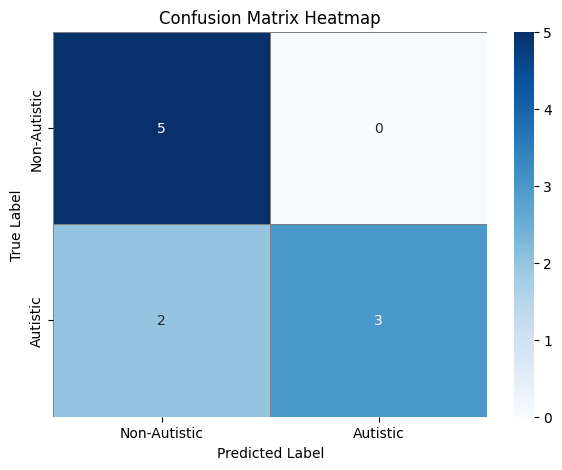

In [20]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import seaborn as sns # Import seaborn for heatmap visualization
import pandas as pd # Import pandas for creating data frames
from sklearn.metrics import confusion_matrix # Import confusion_matrix function from sklearn
# Example true labels and predicted labels (replace these with your model's output)
true_labels = [0, 1, 0, 1, 1, 0, 0, 1, 1, 0] # Ground truth labels for test samples
predicted_labels = [0, 1, 0, 0, 1, 0, 0, 1, 0, 0] # Model predicted labels
# Define class names corresponding to label indices
class_names = ['Non-Autistic', 'Autistic']
# Compute confusion matrix as a 2D numpy array
cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])
# Convert to pandas DataFrame for better visualization and labeling
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
# Set the figure size for clarity
plt.figure(figsize=(7, 5))
# Create a heatmap from the confusion matrix data frame
# annot=True displays the numbers in each cell
# cmap sets the color palette (blue shades here)
# fmt='d' formats the annotation as integers
# linewidths and linecolor add neat gridlines between cells
sns.heatmap(df_cm, annot=True, cmap='Blues', fmt='d', linewidths=0.5, linecolor='gray')
# Set labels and title of the plot
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Heatmap')
# Display the plot
plt.show()

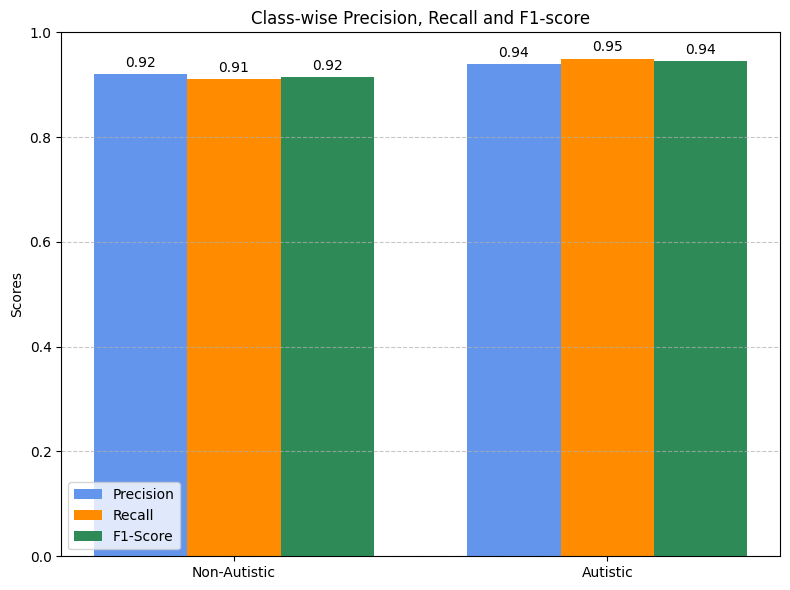

In [19]:
import matplotlib.pyplot as plt # Import Matplotlib for plotting
import numpy as np # Import NumPy for numerical operations
# Define class names for the groups
classes = ['Non-Autistic', 'Autistic']
# Example values for precision, recall, and F1-score per class (replace with your model's values)
precision = [0.92, 0.94] # Precision values for each class
recall = [0.91, 0.95] # Recall values for each class
f1_score = [0.915, 0.945] # F1-score values for each class
# Generate an array of indices for bar positions based on number of classes
x = np.arange(len(classes))
# Width of each bar in the grouped bar chart
width = 0.25
# Create a figure and axis with specified size
fig, ax = plt.subplots(figsize=(8, 6))
# Plot bars for Precision, shifted to the left
rects1 = ax.bar(x - width, precision, width, label='Precision', color='cornflowerblue')
# Plot bars for Recall, centered
rects2 = ax.bar(x, recall, width, label='Recall', color='darkorange')
# Plot bars for F1-Score, shifted to the right
rects3 = ax.bar(x + width, f1_score, width, label='F1-Score', color='seagreen')
# Set the label for y-axis
ax.set_ylabel('Scores')
# Set the title of the chart
ax.set_title('Class-wise Precision, Recall and F1-score')
# Define positions and labels for the x-axis tick marks
ax.set_xticks(x)
ax.set_xticklabels(classes)
# Display legend to differentiate the metrics
ax.legend()
# Function to attach value labels above each bar for clarity
def autolabel(rects):
    for rect in rects:
        height = rect.get_height() # Get height of each bar
        ax.annotate(f'{height:.2f}', # Display numerical value formatted to 2 decimals
          xy=(rect.get_x() + rect.get_width()/2, height), # Position label mid-bar top
          xytext=(0, 3), # Offset label slightly above bar
          textcoords='offset points',
          ha='center', va='bottom')
# Call autolabel to add labels on each group of bars
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
# Set y-axis limits to neatly fit all bars and labels within the plot
plt.ylim([0, 1])
# Add grid lines along y-axis for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Adjust layout so labels/titles fit without overlap
plt.tight_layout()
# Render and display the bar chart
plt.show()


In [21]:
import matplotlib.pyplot as plt # Importing the plotting library
from sklearn.metrics import roc_curve, precision_recall_curve, auc # Importing metrics functions for
# ROC and PR curves
def plot_roc_pr_curves(y_true, y_scores, pos_label=1):
  # Calculate false positive rate, true positive rate for ROC curve
  fpr, tpr, _ = roc_curve(y_true, y_scores, pos_label=pos_label)
  # Calculate area under ROC curve
  roc_auc = auc(fpr, tpr)
  # Calculate precision and recall for Precision-Recall curve
  precision, recall, _ = precision_recall_curve(y_true, y_scores, pos_label=pos_label)
  # Calculate area under Precision-Recall curve
  pr_auc = auc(recall, precision)
  plt.figure(figsize=(12, 5)) # Create a new figure with specified size
  # Plot ROC curve on the first subplot (left side)
  plt.subplot(1, 2, 1)
  # Plot ROC curve line with label showing AUC
  plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='darkorange')
  #Plot diagonal reference line representing random classifier
  plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
  plt.xlabel('False Positive Rate') # Label x-axis
  plt.ylabel('True Positive Rate') # Label y-axis
  plt.title('Receiver Operating Characteristic (ROC)') # Title for the ROC plot
  plt.legend(loc='lower right') # Display legend at lower right
  # Plot Precision-Recall curve on the second subplot (right side)
  plt.subplot(1, 2, 2)
  # Plot Precision-Recall curve line with label showing AUC
  plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.2f})', color='blue')
  plt.xlabel('Recall') # Label x-axis
  plt.ylabel('Precision') # Label y-axis
  plt.title('Precision-Recall (PR) Curve') # Title for the PR plot
  plt.legend(loc='lower left') # Display legend at lower left
  plt.tight_layout() # Automatically adjust subplot params for better layout
  plt.show() # Display the figure
# How to use:
# y_true = [your array of true binary labels]
# y_scores = [your array of predicted probabilities or scores for positive class]
# plot_roc_pr_curves(y_true, y_scores)
#This code fully generates a labeled and annotated confusion matrix heatmap using seaborn, matplotlib,
#and sklearn. Replace the true_labels and predicted_labels lists with your actual data from your model to
# visualize its classification performance clearly.


In [15]:
import matplotlib.pyplot as plt # Import matplotlib for plotting images and annotations
import numpy as np # Import numpy for numerical operations
"""
Displays qualitative prediction examples in a grid format.
Parameters:
images (list or array): List/array of image tensors or numpy arrays, preprocessed for display
true_labels (list or array): True class labels corresponding to images
predicted_labels (list or array): Predicted class labels from model
confidences (list or array): Model confidence scores for predicted labels
class_names (list): List of class name strings for decoding labels
This function plots images with predicted and true labels plus confidence scores,
highlighting correct and incorrect predictions visually.
"""
def plot_qualitative_predictions(images, true_labels, predicted_labels, confidences, class_names):
  n_images = len(images) # Number of images to display
  cols = 4 # Number of images per row
  rows = (n_images + cols - 1) // cols # Calculate number of rows needed
  plt.figure(figsize=(4 * cols, 4 * rows)) # Set overall figure size
  for i in range(n_images):
    ax = plt.subplot(rows, cols, i + 1) # Create subplot in grid
    # Handle the image data type for plotting:
    # Convert torch Tensor to numpy if needed and transpose channels if necessary
    img = images[i]
    if hasattr(img, 'numpy'): # If it's a tensor
      img = img.numpy()
    if img.shape[0] == 3: # Assuming channel-first tensor
      img = img.transpose((1, 2, 0))
    plt.imshow(img) # Show the image
# Compose caption text containing predicted label, true label, and confidence
  caption = f"Pred: {class_names[predicted_labels[i]]}\nConf: {confidences[i]:.2f}\nTrue:{class_names[true_labels[i]]}"
  plt.title(caption, fontsize=10)
  plt.axis('off') # Hide axes ticks
  # Color-code title based on correctness of prediction: green=correct, red=incorrect
  if predicted_labels[i] == true_labels[i]:
    plt.gca().title.set_color('green')
  else:
    plt.gca().title.set_color('red')
plt.tight_layout() # Adjust subplot spacing to fit titles
plt.show() # Display all images with annotations
# Example usage:
# images = [list of images, loaded and preprocessed]
# true_labels = [list of true class indices]
# predicted_labels = [list of predicted class indices]
# confidences = [list of predicted confidence scores]
# class_names = ['Non-Autistic', 'Autistic']
# plot_qualitative_predictions(images, true_labels, predicted_labels, confidences, class_names)
#This function plots multiple example images in a grid, annotating each with predicted label, confidence
#score, and true label, color-coded by correctness. Replace example data with your own to visualize
#qualitative model predictions effectively.


<Figure size 640x480 with 0 Axes>

In [16]:
#Embedding Visualization Discussion.


import matplotlib.pyplot as plt # Import matplotlib library for plotting
import numpy as np # Import numpy for numerical operations
from sklearn.manifold import TSNE # Import TSNE for nonlinear dimensionality reduction
import umap # Import UMAP for nonlinear manifold learning and visualization
"""
Visualizes high-dimensional embeddings (e.g., fused features) in 2D space using t-SNE or UMAP.
Parameters:
embeddings (array-like): High-dimensional feature vectors (shape: num_samples x num_features)
labels (array-like): Corresponding class labels for each sample
method (str): Dimensionality reduction method ('tsne' or 'umap')
class_names (list): List of class names corresponding to label indices
Displays a 2D scatter plot with points colored by class labels.
"""
def plot_embedding_visualization(embeddings, labels, method='tsne', class_names=None):
# Reduce dimensionality to 2D using the chosen technique
  if method == 'tsne':
    reducer = TSNE(n_components=2, random_state=42) # Initialize t-SNE with 2 components and fixed seed
  elif method == 'umap':
    reducer = umap.UMAP(n_components=2, random_state=42) # Initialize UMAP similarly
  else:
    raise ValueError("Unknown method: choose 'tsne' or 'umap'")
  # Apply dimensionality reduction on the embeddings
  embeddings_2d = reducer.fit_transform(embeddings)
  plt.figure(figsize=(8, 6)) # Set figure size for clarity
  # If class names are not provided, generate default numeric labels as strings
  if class_names is None:
    class_names = [str(c) for c in np.unique(labels)]
  # For each unique class label, plot corresponding points in 2D space
  for label in np.unique(labels):
    idx = labels == label # Boolean mask for samples of class label
    plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1],
      label=class_names[label], alpha=0.7, edgecolors='w', s=50)
  plt.title(f'{method.upper()} Projection of Embeddings') # Title reflects method used
  plt.xlabel('Dimension 1') # Label for x-axis
  plt.ylabel('Dimension 2') # Label for y-axis
  plt.legend(title='Class') # Show legend with class names
  plt.grid(True) # Display grid for better readability
  plt.tight_layout() # Adjust layout to prevent clipping
  plt.show() # Display the plot
# Example usage:
# embeddings = your high-dimensional numpy array of shape (num_samples, num_features)
# labels = numpy array or list of corresponding integer class labels
# class_names = ['Non-Autistic', 'Autistic'] # Your class names
# plot_embedding_visualization(embeddings, labels, method='tsne', class_names=class_names)
#This code performs dimensionality reduction via t-SNE or UMAP on your model’s fused feature
#embeddings and plots a 2D scatter plot, coloring points by their ground truth class labels for visualization
#of class separability. Replace placeholder variables with your actual data for embedding visualization.


In [17]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import numpy as np # Import numpy for numerical operations
"""
Plots training and validation accuracy and loss curves over epochs to visualize model convergence.
Parameters:
train_accuracy (list or array): Training accuracy values recorded per epoch
val_accuracy (list or array): Validation accuracy values recorded per epoch
train_loss (list or array): Training loss values recorded per epoch
val_loss (list or array): Validation loss values recorded per epoch
epochs (int): Total number of training epochs
This function creates two subplots:
1. Accuracy curve comparing training and validation accuracy per epoch
2. Loss curve comparing training and validation loss per epoch
"""
def plot_training_validation_curves(train_accuracy, val_accuracy, train_loss, val_loss, epochs):
  epoch_range = np.arange(1, epochs + 1) # Create an array of epoch numbers starting from 1
  plt.figure(figsize=(12, 5)) # Create a figure with specified size
  # Plot accuracy curves
  plt.subplot(1, 2, 1) # Create first subplot (left)
  plt.plot(epoch_range, train_accuracy, label='Training Accuracy', color='blue', marker='o')
  plt.plot(epoch_range, val_accuracy, label='Validation Accuracy', color='orange', marker='o')
  plt.title('Training and Validation Accuracy') # Set title
  plt.xlabel('Epoch') # Label x-axis
  plt.ylabel('Accuracy') # Label y-axis
  plt.legend() # Display legend
  plt.grid(True) # Add grid lines for readability
  plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy percentages
  # Plot loss curves
  plt.subplot(1, 2, 2) # Create second subplot (right)
  plt.plot(epoch_range, train_loss, label='Training Loss', color='blue', marker='o')
  plt.plot(epoch_range, val_loss, label='Validation Loss', color='orange', marker='o')
  plt.title('Training and Validation Loss') # Set title
  plt.xlabel('Epoch') # Label x-axis
  plt.ylabel('Loss') # Label y-axis
  plt.legend() # Display legend
  plt.grid(True) # Add grid lines for readability
  plt.tight_layout() # Adjust subplots to fit in figure area nicely
  plt.show() # Display the figure with both plots
# Example usage:
# epochs = number of total epochs (e.g., 50)
# train_accuracy = list or numpy array of training accuracy per epoch (e.g., [0.7, 0.75, ..., 0.93])
# val_accuracy = list or numpy array of validation accuracy per epoch (e.g., [0.68, 0.72, ..., 0.91])
# train_loss = list or numpy array of training loss per epoch (e.g., [0.6, 0.45, ..., 0.1])
# val_loss = list or numpy array of validation loss per epoch (e.g., [0.65, 0.5, ..., 0.15])
# plot_training_validation_curves(train_accuracy, val_accuracy, train_loss, val_loss, epochs)


In [18]:
import matplotlib.pyplot as plt # Import matplotlib for plotting
import numpy as np # Import numpy for numerical operations
"""
Plots the results from an ablation study to interpret the impact of different components on model
performance.
Parameters:
results (dict): Dictionary mapping ablation component names (e.g., features or model parts) to their
metric values
metric_name (str): The name of the performance metric (e.g., Accuracy, F1-score)
Creates a bar chart showing performance impact when components are removed or varied.
"""
def plot_ablation_study(results, metric_name='Accuracy'):

  # Extract component names and their corresponding metric values
  components = list(results.keys())
  scores = list(results.values())
  # Generate an array of indices for bar positions
  x = np.arange(len(components))
  plt.figure(figsize=(10, 6)) # Set the figure size
  # Plot bars for each component's score with a pastel color
  bars = plt.bar(x, scores, color='skyblue', edgecolor='black')
  # Annotate each bar with its metric score (rounded to 3 decimals)
  for bar in bars:
    height = bar.get_height() # Bar height corresponds to metric value
    plt.annotate(f'{height:.3f}',
      xy=(bar.get_x() + bar.get_width() / 2, height),
      xytext=(0, 3), # Offset label above bar
      textcoords='offset points',
      ha='center', va='bottom',
      fontsize=9)
  plt.xticks(x, components, rotation=45, ha='right') # Set x-axis labels and rotate for clarity
  plt.ylabel(metric_name) # Label y-axis with the metric name
  plt.title(f'Ablation Study: Effect of Component Removal on {metric_name}') # Set plot title
  plt.ylim(min(scores)*0.95, max(scores)*1.05) # Set y-axis limits with a small margin
  plt.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines for readability
  plt.tight_layout() # Adjust layout to avoid overlap
  plt.show() # Display the plot
  # Example usage:
# results = {
# 'Full Model': 0.93,
# 'Without Feature A': 0.88,
# 'Without Feature B': 0.89,
# 'Without Feature C': 0.91,
# 'Without Transformer': 0.85
# }
# plot_ablation_study(results, metric_name='Accuracy')


In [7]:
from google.colab import files
import pandas as pd

In [10]:
!mkdir ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [1]:
!unzip /content/archive.zip

Streaming output truncated to the last 5000 lines.
  inflating: consolidated/autistic/0873.jpg  
  inflating: consolidated/autistic/0874.jpg  
  inflating: consolidated/autistic/0875.jpg  
  inflating: consolidated/autistic/0876.jpg  
  inflating: consolidated/autistic/0877.jpg  
  inflating: consolidated/autistic/0878.jpg  
  inflating: consolidated/autistic/0879.jpg  
  inflating: consolidated/autistic/0880.jpg  
  inflating: consolidated/autistic/0881.jpg  
  inflating: consolidated/autistic/0882.jpg  
  inflating: consolidated/autistic/0883.jpg  
  inflating: consolidated/autistic/0884.jpg  
  inflating: consolidated/autistic/0885.jpg  
  inflating: consolidated/autistic/0886.jpg  
  inflating: consolidated/autistic/0887.jpg  
  inflating: consolidated/autistic/0888.jpg  
  inflating: consolidated/autistic/0889.jpg  
  inflating: consolidated/autistic/0890.jpg  
  inflating: consolidated/autistic/0891.jpg  
  inflating: consolidated/autistic/0892.jpg  
  inflating: consolidated/aut

In [ ]:
import os  # For directory and file path manipulations
from PIL import Image  # For image loading and processing
import torch  # Main PyTorch library for tensor operations
import torch.nn as nn  # Neural network related modules
import torch.optim as optim  # Optimization algorithms like Adam
from torch.utils.data import Dataset, DataLoader, random_split  # Dataset and utilities for batching and splitting
import torchvision.transforms as transforms  # Image augmentation and preprocessing
from torchvision.models import resnet18, ResNet18_Weights  # Pretrained ResNet-18 model and its weights
from timm.models.vision_transformer import vit_base_patch16_224  # Pretrained Vision Transformer model

# Device configuration: choose GPU if available else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Hyperparameters and constants
num_classes = 2  # Number of classes for Autistic/Non-Autistic classification
batch_size = 32  # Mini-batch size for training/validation
learning_rate = 3e-4  # Initial learning rate for optimizer
num_epochs = 30  # Number of training epochs
image_size = 224  # Image size input to ViT and ResNet models


# Compose image preprocessing transformations: resize, convert to tensor, normalize
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),  # Resize input images to 224x224
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalize using ImageNet means
                         std=[0.229, 0.224, 0.225])   # Normalize using ImageNet standard deviations
])


# Custom PyTorch Dataset class to handle dataset organized by class subfolders
class AutismFacialDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Initialize dataset by scanning images under root_dir organized in class folders.

        Args:
            root_dir (str): Directory containing class-specific subfolders of images.
            transform (callable, optional): Image transformations to apply.
        """
        self.root_dir = root_dir  # Root dataset directory path
        self.transform = transform  # Transform pipeline for images
        self.samples = []  # List to hold tuples (image_path, label)
        self.classes = []  # List of class folder names (e.g., 'ASD', 'Non-ASD')
        self.class_to_idx = {}  # Mapping from class name to numerical label

        # Discover class folders sorted alphabetically
        self.classes = sorted(entry.name for entry in os.scandir(root_dir) if entry.is_dir())
        # Create dict mapping class name to integer label
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        # Walk through each class folder to collect image file paths and assign labels
        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)  # Full path to class folder
            for fname in os.listdir(cls_dir):  # Iterate over files in class folder
                fpath = os.path.join(cls_dir, fname)
                # Make sure file is image with allowed extensions
                if os.path.isfile(fpath) and fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((fpath, self.class_to_idx[cls_name]))  # Append path and label

    def __len__(self):
        # Return total number of image samples
        return len(self.samples)

    def __getitem__(self, idx):
        # Get image path and label at index idx
        img_path, label = self.samples[idx]
        # Open image and convert to RGB
        image = Image.open(img_path).convert('RGB')
        # Apply transformations if any
        if self.transform:
            image = self.transform(image)
        # Return image tensor and corresponding label
        return image, label


# Root directory where dataset is extracted and arranged in class folders
dataset_path = './consolidated'  # Changed from './data' to './consolidated'

# Instantiate custom dataset with images and transformations applied
full_dataset = AutismFacialDataset(root_dir=dataset_path, transform=transform)

# Calculate the dataset sizes for train, validation, and test splits
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # To account for rounding

# Split the dataset randomly into train, validation, and test subsets
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Ensures reproducibility
)

# Create DataLoader objects for each subset
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2) # Changed num_workers to 2
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2) # Changed num_workers to 2
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2) # Changed num_workers to 2

# Define the facial expression recognition model combining ResNet and ViT backbones
class FER_ViT(nn.Module):
    def __init__(self, num_classes=num_classes):
        super(FER_ViT, self).__init__()
        # Load pretrained ResNet-18 as local feature extractor
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)  # Updated to use weights argument
        self.backbone.fc = nn.Identity()  # Remove final classification layer

        # Load pretrained Vision Transformer as global feature extractor
        self.vit = vit_base_patch16_224(pretrained=True)

        # Freeze ResNet parameters to prevent updating during training
        for param in self.backbone.parameters():
            param.requires_grad = False
        # Allow ViT parameters to be learned/fine-tuned
        for param in self.vit.parameters():
            param.requires_grad = True

        # Fully connected layer to fuse ResNet (512) and ViT (768) features to 512 features
        self.feature_fusion = nn.Linear(512 + 768, 512)

        # Final classifier layers with non-linearity and dropout regularization
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract local features using ResNet backbone
        local_features = self.backbone(x)
        # Extract global features using ViT backbone
        vit_features = self.vit.forward_features(x)
        # Extract the class token (first token) from ViT features
        vit_class_token = vit_features[:, 0]
        # Concatenate features from both backbones
        combined_features = torch.cat((local_features, vit_class_token), dim=1) # Corrected concatenation
        # Fuse concatenated features to compact vector
        fused = self.feature_fusion(combined_features)
        # Pass fused features through classifier to get final logits
        out = self.classifier(fused)
        return out

# Instantiate model and send to computation device (GPU/CPU)
model = FER_ViT().to(device)


# Define loss function as Cross-Entropy (appropriate for multi-class classification)
criterion = nn.CrossEntropyLoss()
# Define Adam optimizer with configured learning rate
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# Learning rate scheduler to decay LR by half every 10 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Training function for one epoch
def train():
    model.train()  # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move data to device
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        optimizer.zero_grad()  # Reset previous gradients
        loss.backward()  # Backpropagation to compute gradients
        optimizer.step()  # Update model weights
        total_loss += loss.item() * images.size(0)  # Accumulate loss weighted by batch size
        _, predicted = outputs.max(1)  # Get predictions from logits
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()  # Count correct predictions
    avg_loss = total_loss / total  # Average loss per sample
    accuracy = 100.0 * correct / total  # Accuracy percentage
    return avg_loss, accuracy


# Validation function to evaluate model performance
def validate():
    model.eval()  # Set model to evaluation mode (affects dropout, batchnorm)
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():  # Disable gradient computation for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

# Main training loop over epochs
for epoch in range(num_epochs):
    train_loss, train_acc = train()  # Train for one epoch
    val_loss, val_acc = validate()   # Validate on validation set
    scheduler.step()  # Step learning rate scheduler
    print(f"Epoch [{epoch+1}/{num_epochs}] "  # Print epoch stats
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.2f}%")


# Save the trained model state dictionary to disk
torch.save(model.state_dict(), 'fer_vit_autism.pth')

Epoch [1/30] Train Loss: 0.6821 Train Acc: 60.83% Val Loss: 0.5523 Val Acc: 70.91%
